#Loading Dataset

In [ ]:
from scipy.io.arff import loadarff
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np



data = loadarff('column_diagnosis.arff')
df = pd.DataFrame(data[0])
df['class'] = df['class'].str.decode('utf-8')

X = df.drop('class', axis=1)
y = df['class']

#1.a. Ploting two boxplots with the fold accuracies for each classifier.

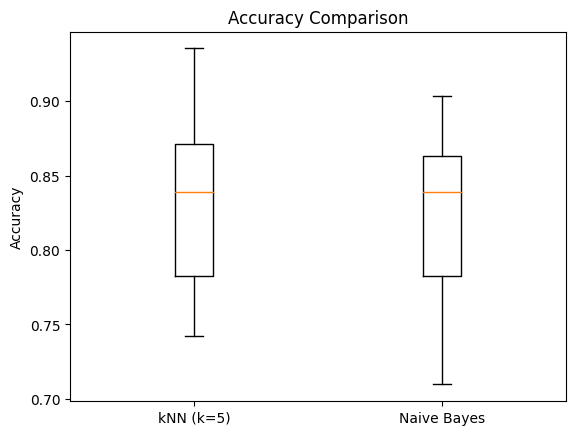

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

scores_knn = cross_val_score(knn, X, y, cv=cv)
scores_nb = cross_val_score(nb, X, y, cv=cv)

plt.boxplot([scores_knn, scores_nb], labels=['kNN (k=5)', 'Naive Bayes'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

Verifying if kNN is statistically superior to naive Bayes regarding
accuracy(using scipy).

In [ ]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(scores_knn, scores_nb)

alpha = 0.05
if p_value < alpha:
    print(f"The difference between kNN and Naive Bayes is statistically significant (p-value = {p_value}).")
else:
    print(f"The difference between kNN and Naive Bayes is not statistically significant (p-value = {p_value}).")

The difference between kNN and Naive Bayes is not statistically significant (p-value = 0.38085618124128184).


#2. Considering two kNN models, one with k = 1, and another with k = 5. Test them on our cross-validation dataset, and then plotting the difference between the cumulative confusion matrices of the models.

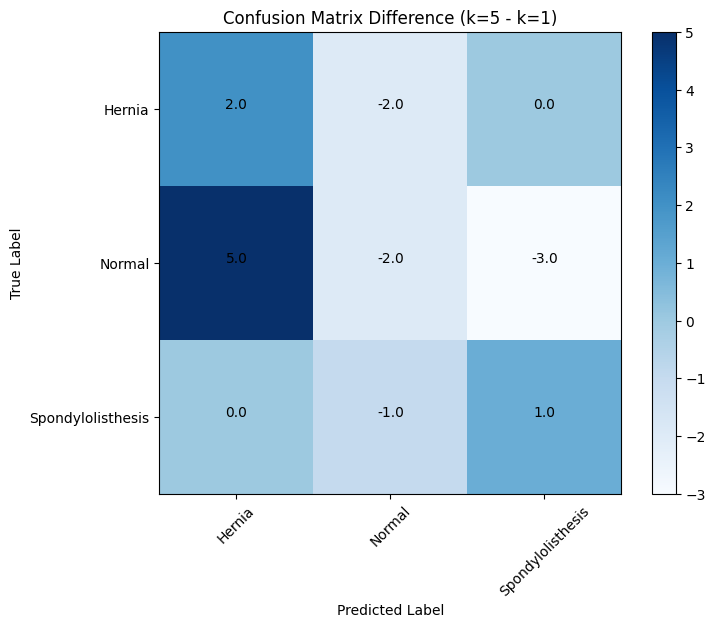

In [ ]:
from sklearn.metrics import confusion_matrix

knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_5 = KNeighborsClassifier(n_neighbors=5)

cum_confusion_1 = np.zeros((3, 3))
cum_confusion_5 = np.zeros((3, 3))

for train_index, test_index in cv.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    knn_1.fit(X_train, y_train)
    y_pred_1 = knn_1.predict(X_test)
    cum_confusion_1 += confusion_matrix(y_test, y_pred_1)

    knn_5.fit(X_train, y_train)
    y_pred_5 = knn_5.predict(X_test)
    cum_confusion_5 += confusion_matrix(y_test, y_pred_5)

diff_confusion = cum_confusion_5 - cum_confusion_1

plt.figure(figsize=(8, 6))
plt.imshow(diff_confusion, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix Difference (k=5 - k=1)')
plt.colorbar()
tick_marks = np.arange(3)
plt.xticks(tick_marks, knn_1.classes_, rotation=45)
plt.yticks(tick_marks, knn_1.classes_)

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(diff_confusion[i, j]), horizontalalignment="center", color="black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

#Comment
As we can see, the differences between the two models are not very noticeable. However, we can still observe minor discrepancies. Our k=5 model correctly identified two additional individuals with hernias and one additional individual with spondylolisthesis compared to the k=1 model. However, it failed to correctly identify two more normal individuals, than other model did. Additionally, our k=5 model falsely classified five individuals with hernias as normal, which is five more than the k=1 model.

<ipython-input-6-6ae1c43af174>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


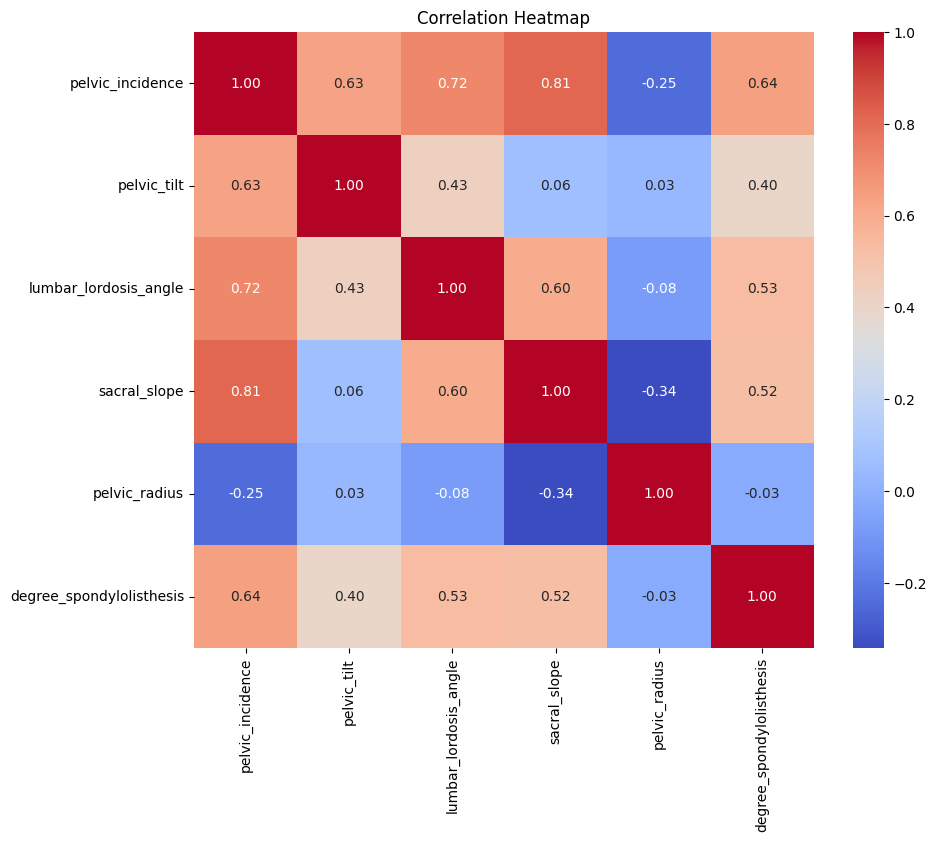

In [ ]:
import seaborn

correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
seaborn.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#3. Identifying three possible difficulties of naive Bayes when learning from the given dataset.

1.   As we can see on the heatmap, the non-target features have correlations between them. Some of them are quite strong, for example, the correlation between sacral slope and pelvic incidence (0.81). So the feature independence assumption used by Naive Bayes can affect negatively preformance of our model.

2.   Continuous numeric features pose a significant challenge. Many features in our dataset are continuous, and this poses a difficulty for our problem. In order to make predictions, the model will need to calculate the probability of features having specific values. While Naive Bayes works well with classes, for numeric values, it requires determining the probability density function for that feature. This function is usually unknown, and attempting to guess it could result in lower predictive power for our model.

3.   Zero frequencies are also a problem we should consider. As we mentioned earlier, our model needs to calculate the probability of features in order to predict a target feature. Therefore, calculating a probability for a value never seen in the training dataset, or for a value that falls outside the observed range, could also result in lower predictive power.


